Task 3 - Classification Models
1. Use a dataset (like Titanic) to build a classification model that predicts a categorical target variable (e.g., survived/not survived).

2. Compare at least two classifiers (e.g., Logistic Regression vs Decision Tree).

3. Evaluate your model using a confusion matrix, accuracy, precision, recall, and F1-score.

dataset link : -# dataset = https://www.kaggle.com/datasets/yasserh/titanic-dataset?select=Titanic-Dataset.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.linear_model import Lasso,Ridge,LassoCV,RidgeCV,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
import math
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier


In [89]:
data = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
print("Shape:", data.shape)
data.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [92]:
data['Age'].fillna(data['Age'].mean(),inplace=True)
data.drop(columns=['Cabin'],axis=1,inplace=True)
data.dropna(inplace=True)
x = data.drop(columns=['Survived','Name'],axis=1)
y = data['Survived']


C:\Users\user\AppData\Local\Temp\ipykernel_28924\738555639.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)


['Sex', 'Ticket', 'Embarked']


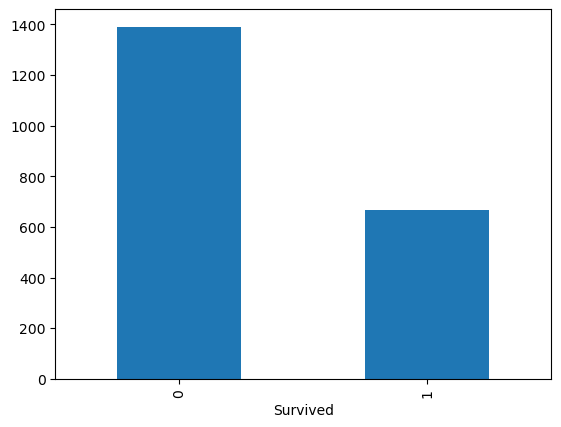

In [ ]:
data.groupby('Survived')['Pclass'].sum().plot(kind='bar')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.2,random_state = 0)
col = [x for x in x_train.columns if x_train[x].dtype == "object"]
print(col)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
for c in col:
    encoder.fit(x_train[col])
    x_train[col] = encoder.transform(x_train[col])
    x_test[col] = encoder.transform(x_test[col])

In [94]:
Logistic = LogisticRegression()
Logistic.fit(x_train,y_train)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [95]:
print(Logistic.coef_,Logistic.intercept_)

[[ 6.90158673e-04  8.90544875e-02 -2.63559138e+00 -1.32143627e-02
  -3.84179132e-01 -2.46544075e-01 -1.21087671e-03  1.90137893e-02
   4.52833329e-02]] [0.8621893]


In [96]:
y_pred = Logistic.predict(x_test)

In [97]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
Logistic_Regression = classification_report(y_test,y_pred)
print("accuracy_score : ",accuracy_score(y_pred,y_test))


accuracy_score :  0.7191011235955056


In [98]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(x_train,y_train)

DecisionTreeClassifier()

In [99]:
y_pred = decision_tree.predict(x_test)

In [100]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
decision_tree = classification_report(y_test,y_pred)
print("accuracy_score : ",accuracy_score(y_pred,y_test))


accuracy_score :  0.6179775280898876


In [101]:
print("LogisticRegression")
print(Logistic_Regression)
print("Decison Tree")
print(decision_tree)

LogisticRegression
              precision    recall  f1-score   support

           0       0.74      0.80      0.77       105
           1       0.68      0.60      0.64        73

    accuracy                           0.72       178
   macro avg       0.71      0.70      0.70       178
weighted avg       0.72      0.72      0.72       178

Decison Tree
              precision    recall  f1-score   support

           0       0.68      0.66      0.67       105
           1       0.53      0.56      0.55        73

    accuracy                           0.62       178
   macro avg       0.61      0.61      0.61       178
weighted avg       0.62      0.62      0.62       178

